# De la Decizii Simple la Inteligență Artificială Complexă

Un Proces de Decizie Markov (PDM) este un cadru matematic utilizat pentru modelarea luării deciziilor. Este util în situațiile în care deciziile au consecințe pe termen scurt și lung, și sunt parțial aleatorii sau scapă controlului decidentului. 

Formal, un MDP este compus din următoarele elemente de bază:
* **Mulțimea stărilor $S$**, considerată finită ($S=\{s_0, s_1, ..., s_n\}$).
* **Mulțimea acțiunilor $A = \cup_{s \in S} A_s$**, unde $A_s$ indică acțiunile pe care un agent aflat în starea $s$ le poate efectua.
* **Funcția de tranziție $T(s,a,s')$**: Exprimă probabilitatea ca un agent aflat în starea $s \in S$ și care execută acțiunea $a \in A$ să ajungă într-o stare $s' \in S$. O condiție necesară a funcției de tranziție este legată de proprietatea Markov, sau proprietatea de absență a memoriei (memoryless property), care afirmă că viitorul depinde strict de starea prezentă, nu și de stările trecute. Probabilitatea de a ajunge într-o stare $s'$ la momentul $t+1$ depinde doar de starea $s$ și acțiunea $a$ luate la momentul $t$. Aceste probabilități sunt codificate astfel: $T(s,a,s') = P(s'|s,a)$.
* **Funcția de recompensă $R(s,a,s')$**: Recompensele pot fi pozitive sau negative, în funcție de cât de favorabile sunt pentru agent, iar obiectivul agentului este, în mod natural, să obțină recompensa maximă posibilă înainte de a ajunge într-o stare terminală.
* **Factorul de actualizare $\gamma$**: O valoare între 0 și 1 care determină importanța recompenselor viitoare. O valoare mai mică pune accent pe recompensele imediate, în timp ce o valoare mai mare echilibrează recompensele prezente cu cele viitoare.

Scopul final este de a determina o politică/strategie optimă $\pi^*: S \rightarrow A$, care asociază fiecărei stări $s \in S$ o acțiune $a \in A$ pentru a maximiza utilitatea actualizată (discounted utility):
$$U([s_0, a_0, s_1, a_1, ...]) = R(s_0, a_0, s_1) + \gamma R(s_1, a_1, s_2) + \gamma^2 R(s_2, a_2, s_3) + ...$$

Matematic, rezolvarea problemei se bazează pe **Ecuația Bellman**, care exprimă utilitatea optimă a unei stări:
$$V^*(s) = \max_{a \in A} \sum_{s' \in S} T(s,a,s')[R(s,a,s') + \gamma V^*(s')]$$

## Învățarea prin Întărire (Reinforcement Learning) și Q-Learning

Atunci când agentul nu cunoaște funcția de tranziție $T$ și funcția de recompensă $R$, intrăm în domeniul Reinforcement Learning. Învățarea prin întărire permite mașinilor să învețe prin interacțiunea cu un mediu și prin primirea de feedback bazat pe acțiunile lor.

Unul dintre cei mai revoluționari algoritmi fără model este **Q-Learning**, care propune învățarea directă a valorilor-Q ale stărilor, complet independent de model. Algoritmul utilizează următoarea regulă de actualizare iterativă:
$$Q_{k+1}(s,a) = (1 - \alpha)Q_k(s,a) + \alpha \cdot [R(s,a,s') + \gamma \max_{a'} Q_k(s',a')]$$

Pentru a descoperi stări noi, agenții folosesc strategii de tipul explorare vs. exploatare, cum ar fi politica $\epsilon$-greedy, în care acționează aleatoriu și explorează cu probabilitatea $\epsilon$, iar cu probabilitatea $1-\epsilon$ exploatează alegând acțiunea optimă cunoscută $\arg\max_a Q(s,a)$ .

Limita majoră a acestor metode clasice este **Blestemul Dimensionalității**. Când spațiul stărilor crește, tabelul $Q(s,a)$ devine imposibil de stocat. Aici intervine **Deep Reinforcement Learning** (folosirea Rețelelor Neuronale pentru a aproxima funcțiile de valoare și decizie) combinat cu **Monte Carlo Tree Search (MCTS)**.

In [2]:
import numpy as np
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import trange
import random

# Fixăm seed-urile pentru reproductibilitate
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print(f"PyTorch Version: {torch.__version__}")
print(f"NumPy Version: {np.__version__}")

PyTorch Version: 2.4.1+cpu
NumPy Version: 2.4.3


## Partea I - AlphaZero pentru Jocuri Zero-Sum (Connect Four)

Vom modela problema jocurilor în doi jucători (Zero-Sum) sub forma unui MDP:
* **Stările ($S$)**: Configurația exactă a pieselor pe tabla de joc.
* **Acțiunile ($A$)**: Mutările valide permise de regulament.
* **Tranziția ($T$)**: Deterministă.
* **Recompensa ($R$)**: $+1$ pentru victorie, $-1$ pentru înfrângere, $0$ pe parcursul jocului.

Mai jos vom defini mediile de joc, incluzând metode esențiale precum `change_perspective`, necesară pentru a juca "împotriva propriei persoane" (Self-Play).

In [3]:
class TicTacToe:
    def __init__(self):
        self.row_count = 3
        self.column_count = 3
        self.action_size = self.row_count * self.column_count

    def __repr__(self):
        return "TicTacToe"
        
    def get_initial_state(self):
        return np.zeros((self.row_count, self.column_count))

    def get_next_state(self, state, action, player):
        row = action // self.column_count 
        column = action % self.column_count 
        state[row, column] = player
        return state

    def get_valid_moves(self, state):
        return (state.reshape(-1) == 0).astype(np.uint8)

    def check_win(self, state, action):
        if action == None:
            return False
        
        row = action // self.column_count 
        column = action % self.column_count
        player = state[row, column]

        return (
            np.sum(state[row, :]) == player * self.column_count
            or np.sum(state[:, column]) == player * self.row_count
            or np.sum(np.diag(state)) == player * self.row_count 
            or np.sum(np.diag(np.flip(state, axis=0))) == player * self.row_count 
        )

    def get_value_and_terminated(self, state, action):
        if self.check_win(state, action):
            return 1, True
        if np.sum(self.get_valid_moves(state)) == 0:
            return 0, True
        return 0, False

    def get_opponent(self, player):
        return -player

    def get_opponent_value(self, value):
        return -value

    def change_perspective(self, state, player):
        return state * player

    def get_encoded_state(self, state):
        encoded_state = np.stack(
            (state == -1, state == 0, state == 1)
        ).astype(np.float32)

        if len(state.shape) == 3:
            encoded_state = np.swapaxes(encoded_state, 0, 1)
        return encoded_state

class ConnectFour:
    def __init__(self):
        self.row_count = 6
        self.column_count = 7
        self.action_size = self.column_count
        self.in_a_row = 4

    def __repr__(self):
        return "ConnectFour"
        
    def get_initial_state(self):
        return np.zeros((self.row_count, self.column_count))

    def get_next_state(self, state, action, player):
        row = np.max(np.where(state[:, action] == 0))
        state[row, action] = player
        return state

    def get_valid_moves(self, state):
        return (state[0] == 0).astype(np.uint8)

    def check_win(self, state, action):
        if action == None:
            return False
        
        row = np.min(np.where(state[:, action] != 0))
        column = action
        player = state[row][column]

        def count(offset_row, offset_column):
            for i in range(1, self.in_a_row):
                r = row + offset_row * i
                c = action + offset_column * i
                if (
                    r < 0 or r >= self.row_count or c < 0 or c >= self.column_count
                    or state[r][c] != player
                ):
                    return i - 1
            return self.in_a_row - 1

        return(
            count(1, 0) >= self.in_a_row - 1 
            or (count(0, 1) + count(0, -1)) >= self.in_a_row - 1 
            or (count(1, 1) + count(-1, -1)) >= self.in_a_row - 1 
            or (count(1, -1) + count(-1, 1)) >= self.in_a_row - 1 
        )

    def get_value_and_terminated(self, state, action):
        if self.check_win(state, action):
            return 1, True
        if np.sum(self.get_valid_moves(state)) == 0:
            return 0, True
        return 0, False

    def get_opponent(self, player):
        return -player

    def get_opponent_value(self, value):
        return -value

    def change_perspective(self, state, player):
        return state * player

    def get_encoded_state(self, state):
        encoded_state = np.stack(
            (state == -1, state == 0, state == 1)
        ).astype(np.float32)

        if len(state.shape) == 3:
            encoded_state = np.swapaxes(encoded_state, 0, 1)
        return encoded_state

## Arhitectura Rețelei Neuronale (ResNet)

Deoarece intrările sunt table de joc bidimensionale, folosim o Rețea Convoluțională Reziduală (ResNet). Rețeaua produce **două output-uri**:
1.  **Policy Head (Politica $\pi$)**: Estimează un vector de probabilități pentru acțiunile disponibile.
2.  **Value Head (Valoarea $V$)**: Un scalar care estimează cine este mai probabil să câștige din această configurație.

In [4]:
class ResBlock(nn.Module):
    def __init__(self, num_hidden):
        super().__init__()
        self.conv1 = nn.Conv2d(num_hidden, num_hidden, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(num_hidden)
        self.conv2 = nn.Conv2d(num_hidden, num_hidden, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(num_hidden)

    def forward(self, x):
        residual = x
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x += residual
        x = F.relu(x)
        return x

class ResNet(nn.Module):
    def __init__(self, game, num_resBlocks, num_hidden, device):
        super().__init__()
        self.device = device
        
        self.startBlock = nn.Sequential(
            nn.Conv2d(3, num_hidden, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_hidden),
            nn.ReLU()
        )

        self.backBone = nn.ModuleList(
            [ResBlock(num_hidden) for i in range(num_resBlocks)]
        )

        self.policyHead = nn.Sequential(
            nn.Conv2d(num_hidden, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * game.row_count * game.column_count, game.action_size)
        )

        self.valueHead = nn.Sequential(
            nn.Conv2d(num_hidden, 3, kernel_size=3, padding=1), 
            nn.BatchNorm2d(3),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(3 * game.row_count * game.column_count, 1),
            nn.Tanh()
        )

        self.to(device)

    def forward(self, x):
        x = self.startBlock(x)
        for resBlock in self.backBone:
            x = resBlock(x)
        policy = self.policyHead(x)
        value = self.valueHead(x)
        return policy, value

## Monte Carlo Tree Search (MCTS)

MCTS simulează viitorul construind un arbore de decizie, ghidat de rețeaua neuronală.



Folosește formula **PUCT** pentru a echilibra explorarea cu exploatarea:
$$U(s,a) = Q(s,a) + C \cdot P(s,a) \cdot \frac{\sqrt{N(s)}}{1 + N(s,a)}$$

In [5]:
class Node:
    def __init__(self, game, args, state, parent=None, action_taken=None, prior=0, visit_count=0):
        self.game = game
        self.args = args
        self.state = state
        self.parent = parent
        self.action_taken = action_taken
        self.prior = prior

        self.children = []
        self.visit_count = visit_count
        self.value_sum = 0

    def is_fully_expanded(self):
        return len(self.children) > 0

    def select(self):
        best_child = None
        best_ucb = -np.inf

        for child in self.children:
            ucb = self.get_ucb(child)
            if ucb > best_ucb:
                best_child = child
                best_ucb = ucb
        return best_child

    def get_ucb(self, child):
        if child.visit_count == 0:
            q_value = 0
        else:
            q_value = 1 - ((child.value_sum / child.visit_count) + 1) / 2
        
        return q_value + self.args['C'] * (math.sqrt(self.visit_count) / (child.visit_count + 1)) * child.prior

    def expand(self, policy):
        for action, prob in enumerate(policy):
            if prob > 0:
                child_state = self.state.copy()
                child_state = self.game.get_next_state(child_state, action, 1)
                child_state = self.game.change_perspective(child_state, player=-1)

                child = Node(self.game, self.args, state=child_state, parent=self, action_taken=action, prior=prob)
                self.children.append(child)

    def backpropagate(self, value):
        self.value_sum += value
        self.visit_count += 1
        value = self.game.get_opponent_value(value) 
        if self.parent is not None:
            self.parent.backpropagate(value)

class MCTS:
    def __init__(self, game, args, model):
        self.game = game
        self.args = args
        self.model = model
        
    @torch.no_grad()
    def search(self, state, current_num_searches=None):
        if current_num_searches is None:
            current_num_searches = self.args['num_searches']

        root = Node(self.game, self.args, state, visit_count=1)

        policy, _ = self.model(
            torch.tensor(self.game.get_encoded_state(state), device=self.model.device).unsqueeze(0)
        )
        policy = torch.softmax(policy, axis=1).squeeze(0).cpu().numpy()

        policy = (1 - self.args['dirichlet_epsilon']) * policy + self.args['dirichlet_epsilon'] * np.random.dirichlet([self.args['dirichlet_alpha']] * self.game.action_size)

        valid_moves = self.game.get_valid_moves(state)
        policy *= valid_moves
        policy /= np.sum(policy)
        root.expand(policy)

        for search in range(current_num_searches):
            node = root
            
            while node.is_fully_expanded():
                node = node.select()

            value, is_terminal = self.game.get_value_and_terminated(node.state, node.action_taken)
            value = self.game.get_opponent_value(value)
            
            if not is_terminal:
                policy, value = self.model(
                    torch.tensor(self.game.get_encoded_state(node.state), device=self.model.device).unsqueeze(0) 
                )
                policy = torch.softmax(policy, axis=1).squeeze(0).cpu().numpy()
                valid_moves = self.game.get_valid_moves(node.state)
                policy *= valid_moves
                policy /= np.sum(policy)
                value = value.item()
                
                node.expand(policy)
          
            node.backpropagate(value)
            
        action_probs = np.zeros(self.game.action_size)
        for child in root.children:
            action_probs[child.action_taken] = child.visit_count
            
        action_probs /= np.sum(action_probs)
        return action_probs

## Algoritmul Principal AlphaZero (Self-Play & Train)

Agentul joacă partide împotriva sa (`selfPlay()`). Aceste experiențe populează o "memorie" utilizată pentru Îmbunătățirea Politicii (`train()`). Optimizarea se face folosind funcția combinată de pierdere (Loss Function):
$$L(\theta) = (z - V_\theta(s))^2 - \boldsymbol{\pi}^T \log \pi_\theta(s) + c||\theta||^2$$

In [6]:
class AlphaZero:
    def __init__(self, model, optimizer, game, args):
        self.model = model
        self.optimizer = optimizer
        self.game = game
        self.args = args
        self.mcts = MCTS(game, args, model)

    def selfPlay(self):
        memory = []
        player = 1
        state = self.game.get_initial_state()

        while True:
            neutral_state = self.game.change_perspective(state, player)

            if np.random.random() < self.args['prob_full_search']:
                searches = self.args['num_searches'] 
            else:
                searches = self.args['num_searches_fast'] 
            
            action_probs = self.mcts.search(neutral_state, current_num_searches=searches)

            memory.append((neutral_state, action_probs, player))
            temperature_action_probs = action_probs ** (1 / self.args['temperature'])
            action = np.random.choice(self.game.action_size, p=action_probs)

            state = self.game.get_next_state(state, action, player)
            value, is_terminal = self.game.get_value_and_terminated(state, action)

            if is_terminal:
                returnMemory = []
                for hist_neutral_state, hist_action_probs, hist_player in memory:
                    hist_outcome = value if hist_player == player else self.game.get_opponent_value(value)
                    returnMemory.append((
                        self.game.get_encoded_state(hist_neutral_state),
                        hist_action_probs,
                        hist_outcome
                    ))
                return returnMemory

            player = self.game.get_opponent(player)

    def train(self, memory):
        random.shuffle(memory)
        for batchIdx in range(0, len(memory), self.args['batch_size']):
            sample = memory[batchIdx:min(len(memory) - 1, batchIdx + self.args['batch_size'])]
            state, policy_targets, value_targets = zip(*sample)

            state, policy_targets, value_targets = np.array(state), np.array(policy_targets), np.array(value_targets).reshape(-1, 1)

            state = torch.tensor(state, dtype=torch.float32, device=self.model.device)
            policy_targets = torch.tensor(policy_targets, dtype=torch.float32, device=self.model.device)
            value_targets = torch.tensor(value_targets, dtype=torch.float32, device=self.model.device)

            out_policy, out_value = self.model(state)

            policy_loss = F.cross_entropy(out_policy, policy_targets)
            value_loss = F.mse_loss(out_value, value_targets)
            loss = policy_loss + value_loss

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

    def learn(self):
        for iteration in range(self.args['num_iterations']):
            memory = []

            self.model.eval()
            for selfPlay_iteration in trange(self.args['num_selfPlay_iterations'], desc=f"SelfPlay Iter {iteration}"):
                memory += self.selfPlay()

            self.model.train()
            for epoch in trange(self.args['num_epochs'], desc=f"Train Epochs {iteration}"):
                self.train(memory)

In [20]:
game = ConnectFour()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet(game, 9, 128, device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

args = {
    'C': 2,
    'num_searches': 60,           
    'num_searches_fast': 15,      
    'prob_full_search': 0.25,     
    'num_iterations': 5,          
    'num_selfPlay_iterations': 50,
    'num_epochs': 4,
    'batch_size': 64,
    'temperature': 1.25,
    'dirichlet_epsilon': 0.25,
    'dirichlet_alpha': 0.3
}

print("=== Antrenament AlphaZero: Connect Four ===")
alphaZero = AlphaZero(model, optimizer, game, args)
alphaZero.learn()
print("Antrenament finalizat cu succes!")

=== Antrenament AlphaZero: Connect Four ===


Train Epochs 4: 100%|████████████████████████████| 4/4 [00:07<00:00,  1.99s/it]

Antrenament finalizat cu succes!


[[ 0.  0. -1.]
 [ 0. -1.  0.]
 [ 1.  0.  1.]]
[[[0. 0. 1.]
  [0. 1. 0.]
  [0. 0. 0.]]

 [[1. 1. 0.]
  [1. 0. 1.]
  [0. 1. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [1. 0. 1.]]]
0.22261294722557068 [0.10596954 0.11408453 0.10476182 0.11021881 0.11036345 0.12280536
 0.11140806 0.1091364  0.11125199]


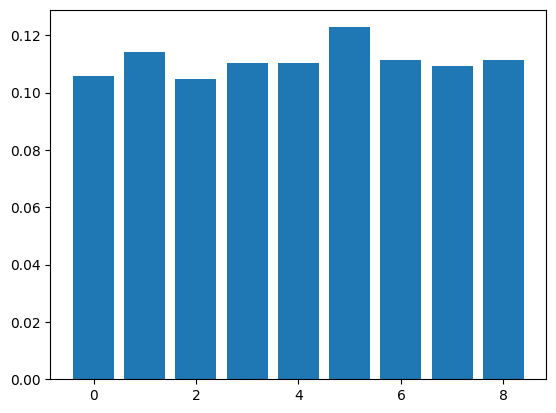

In [21]:
import matplotlib.pyplot as plt
import torch

tictactoe = TicTacToe()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

state = tictactoe.get_initial_state()
state = tictactoe.get_next_state(state, 2, -1)
state = tictactoe.get_next_state(state, 4, -1)
state = tictactoe.get_next_state(state, 6, 1)
state = tictactoe.get_next_state(state, 8, 1)

print(state)

encoded_state = tictactoe.get_encoded_state(state)
print(encoded_state)

tensor_state = torch.tensor(encoded_state, device=device).unsqueeze(0)
model = ResNet(tictactoe, 4, 64, device=device)

# PUNE UN # AICI PENTRU A IGNORA ÎNCĂRCAREA FIȘIERULUI
# model.load_state_dict(torch.load('model_2.pt', map_location=device, weights_only=True))

model.eval()

policy, value = model(tensor_state)
value = value.item()

policy = torch.softmax(policy, axis=1).squeeze(0).detach().cpu().numpy()

print(value, policy)

plt.bar(range(tictactoe.action_size), policy)
plt.show()

## Partea II - AlphaZero aplicat în Telecomunicații (Problema Alocării Frecvențelor - FAP)

Problema Alocării Frecvențelor (Frequency Assignment Problem) constă în distribuirea optimă a spectrului radio disponibil pe un număr de turnuri telecom, minimizând interferența. 

Formularea problemei Single-Agent ca MDP:
* **Stările ($S$)**: Vector ce conține indexul turnului curent și configurația curentă de frecvențe. 
* **Acțiunile ($A$)**: Setul de frecvențe disponibile $\{0, 1, ..., K-1\}$.
* **Funcția de Tranziție ($T$)**: Dacă agentul alocă o frecvență, avansează indexul turnului.
* **Funcția de recompensă ($R$)**: Penalizare proporțională cu interferența totală generată, calculată la final.

In [22]:
class FrequencyEnvironment:
    def __init__(self, num_towers=7, num_frequencies=3, map_size=100):
        self.num_towers = num_towers
        self.num_frequencies = num_frequencies
        self.action_size = num_frequencies 
        
        self.tower_coords = np.random.randint(0, map_size, size=(num_towers, 2))
        self.interference_matrix = np.zeros((num_towers, num_towers), dtype=np.float32)
        
        for i in range(num_towers):
            for j in range(num_towers):
                if i != j:
                    dist = np.linalg.norm(self.tower_coords[i] - self.tower_coords[j])
                    if dist < 40:
                        self.interference_matrix[i, j] = 100.0 / (dist + 1.0)
                        
        self.max_possible_interference = np.sum(self.interference_matrix) / 2.0
        
    def __repr__(self):
        return "FrequencyAssignment_Offline"

    def get_initial_state(self):
        state = np.zeros(1 + self.num_towers, dtype=np.float32)
        state[0] = 0 
        state[1:] = -1 
        return state

    def get_next_state(self, state, action, player=1):
        next_state = np.copy(state)
        current_tower = int(next_state[0])
        next_state[1 + current_tower] = action 
        next_state[0] += 1                     
        return next_state

    def get_valid_moves(self, state):
        return np.ones(self.action_size, dtype=np.uint8)

    def get_value_and_terminated(self, state, action):
        current_tower = int(state[0])
        if current_tower < self.num_towers:
            return 0.0, False 
            
        frequencies = state[1:]
        total_interference = 0.0
        
        for i in range(self.num_towers):
            for j in range(i + 1, self.num_towers):
                if frequencies[i] == frequencies[j]:
                    total_interference += self.interference_matrix[i, j]
                    
        if total_interference == 0:
            value = 1.0 
        else:
            penalty = total_interference / (self.max_possible_interference + 1e-5)
            value = 1.0 - (2.0 * penalty)
            
        return max(-1.0, min(1.0, value)), True

    def get_encoded_state(self, state):
        current_tower = state[0] / self.num_towers 
        frequencies = state[1:]
        
        freq_encoded = np.zeros((self.num_towers, self.num_frequencies), dtype=np.float32)
        for i, f in enumerate(frequencies):
            if f != -1: 
                freq_encoded[i, int(f)] = 1.0
                
        encoded = np.concatenate([
            [current_tower],
            freq_encoded.flatten(),
            self.interference_matrix.flatten() / 100.0 
        ])
        return encoded.astype(np.float32)

    def get_opponent(self, player): return player
    def get_opponent_value(self, value): return value
    def change_perspective(self, state, player): return state

def draw_network(env, state):
    frequencies = state[1:]
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    
    plt.figure(figsize=(6, 6))
    for i in range(env.num_towers):
        for j in range(i + 1, env.num_towers):
            if env.interference_matrix[i, j] > 0:
                plt.plot([env.tower_coords[i, 0], env.tower_coords[j, 0]], 
                         [env.tower_coords[i, 1], env.tower_coords[j, 1]], 
                         'k--', alpha=0.2)
                
    for i in range(env.num_towers):
        freq = int(frequencies[i])
        color = colors[freq] if freq != -1 else 'gray'
        plt.scatter(env.tower_coords[i, 0], env.tower_coords[i, 1], 
                    c=color, s=500, edgecolors='black', zorder=5)
        plt.text(env.tower_coords[i, 0], env.tower_coords[i, 1], f"T{i}", 
                 color='white', ha='center', va='center', fontweight='bold')
        
    plt.title(f"Alocarea Frecvențelor (Graful de Interferență)")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

## Rețeaua Neuronală și UCB Adaptat (Single-Agent)

Deoarece starea în mediul FAP nu mai este o imagine 2D, folosim o arhitectură densă Multi-Layer Perceptron (MLP) `FAP_MLP`.

În plus, modificăm ecuația UCB din MCTS. La jocuri Zero-Sum trebuia să "inversăm" probabilitatea victoriilor oponentului. În optimizarea Single-Agent, valoarea stării viitoare este direct proporțională cu interesul nostru:
$$Q(s,a) = \frac{\frac{W(s,a)}{N(s,a)} + 1}{2}$$

In [23]:
class FAP_MLP(nn.Module):
    def __init__(self, env, num_hidden=128, device='cpu'):
        super().__init__()
        self.device = device
        self.action_size = env.action_size 
        
        self.input_size = 1 + (env.num_towers * env.num_frequencies) + (env.num_towers ** 2)
        
        self.fc1 = nn.Linear(self.input_size, num_hidden)
        self.ln1 = nn.LayerNorm(num_hidden) 
        
        self.fc2 = nn.Linear(num_hidden, num_hidden)
        self.ln2 = nn.LayerNorm(num_hidden)
        
        self.policy_fc = nn.Linear(num_hidden, self.action_size)
        
        self.value_fc1 = nn.Linear(num_hidden, 32)
        self.value_fc2 = nn.Linear(32, 1)

        self.to(device)

    def forward(self, x):
        x = x.view(x.size(0), -1) 
        x = F.relu(self.ln1(self.fc1(x)))
        x = F.relu(self.ln2(self.fc2(x)))
        
        policy = self.policy_fc(x)
        v = F.relu(self.value_fc1(x))
        value = torch.tanh(self.value_fc2(v)) 
        
        return policy, value

class NodeFAP:
    def __init__(self, game, args, state, parent=None, action_taken=None, prior=0, visit_count=0):
        self.game = game
        self.args = args
        self.state = state
        self.parent = parent
        self.action_taken = action_taken
        self.prior = prior
        self.children = []
        self.visit_count = visit_count
        self.value_sum = 0

    def is_fully_expanded(self):
        return len(self.children) > 0

    def select(self):
        best_child = None
        best_ucb = -np.inf
        for child in self.children:
            ucb = self.get_ucb(child)
            if ucb > best_ucb:
                best_child = child
                best_ucb = ucb
        return best_child

    def get_ucb(self, child):
        if child.visit_count == 0:
            q_value = 0
        else:
            q_value = ((child.value_sum / child.visit_count) + 1) / 2
            
        return q_value + self.args['C'] * (math.sqrt(self.visit_count) / (child.visit_count + 1)) * child.prior

    def expand(self, policy):
        for action, prob in enumerate(policy):
            if prob > 0:
                child_state = self.state.copy()
                child_state = self.game.get_next_state(child_state, action, 1)
                child = NodeFAP(self.game, self.args, state=child_state, parent=self, action_taken=action, prior=prob)
                self.children.append(child)

    def backpropagate(self, value):
        self.value_sum += value
        self.visit_count += 1
        if self.parent is not None:
            self.parent.backpropagate(value)

class MCTSFAP:
    def __init__(self, game, args, model):
        self.game = game
        self.args = args
        self.model = model 
        
    @torch.no_grad()
    def search(self, state, current_num_searches=None):
        if current_num_searches is None:
            current_num_searches = self.args['num_searches']

        root = NodeFAP(self.game, self.args, state, visit_count = 1)
        policy, _ = self.model(
            torch.tensor(self.game.get_encoded_state(state), device = self.model.device).unsqueeze(0)
        )
        policy = torch.softmax(policy, axis=1).squeeze(0).cpu().numpy()
        policy = (1 - self.args['dirichlet_epsilon']) * policy + self.args['dirichlet_epsilon'] * np.random.dirichlet([self.args['dirichlet_alpha']] * self.game.action_size)
        valid_moves = self.game.get_valid_moves(state)
        policy *= valid_moves
        policy /= np.sum(policy)
        root.expand(policy)

        for search in range(current_num_searches):
            node = root
            while node.is_fully_expanded():
                node = node.select()
                
            value, is_terminal = self.game.get_value_and_terminated(node.state, node.action_taken)
            
            if not is_terminal:
                policy, value = self.model(
                    torch.tensor(self.game.get_encoded_state(node.state), device = self.model.device).unsqueeze(0) 
                )
                policy = torch.softmax(policy, axis=1).squeeze(0).cpu().numpy()
                valid_moves = self.game.get_valid_moves(node.state)
                policy *= valid_moves
                policy /= np.sum(policy)
                value = value.item()
                node.expand(policy)
          
            node.backpropagate(value)
            
        action_probs = np.zeros(self.game.action_size)
        for child in root.children:
            action_probs[child.action_taken] = child.visit_count
            
        action_probs /= np.sum(action_probs)
        return action_probs

## Antrenare și Implementare Single-Agent

Execuția de antrenament este similară cu cea a jocurilor competitive, dar se bazează pe clasa de MCTS izolată anterior. Vom instanția problema pentru 7 turnuri și 3 frecvențe.


=== Începem antrenamentul AlphaZero pentru FAP (7 Turnuri) ===


Training Epochs 2: 100%|█████████████████████████| 4/4 [00:00<00:00, 85.66it/s]


Antrenament FAP finalizat!

=== AI-ul rezolvă rețeaua acum ===
Alocare finalizată de AI! Frecvențe: [0. 1. 0. 0. 1. 2. 2.]
Recompensa: 0.590 (1.0 = Fără nicio interferență)


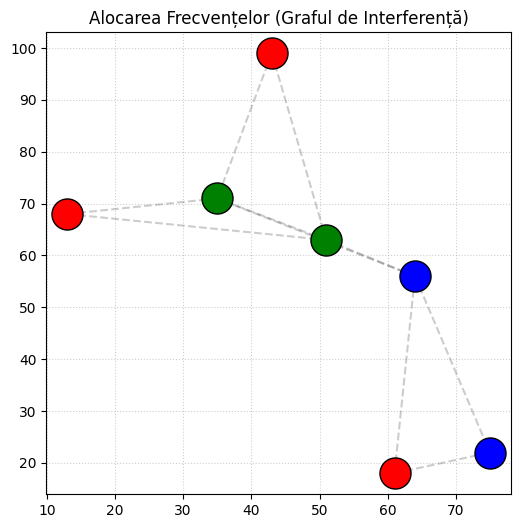

In [24]:
class AlphaZeroFAP:
    def __init__ (self, model, optimizer, game, args):
        self.model = model
        self.optimizer = optimizer
        self.game = game
        self.args = args
        self.mcts = MCTSFAP(game, args, model)

    def selfPlay(self):
        memory = []
        player = 1
        state = self.game.get_initial_state()

        while True:
            neutral_state = state
            
            if np.random.random() < self.args['prob_full_search']:
                searches = self.args['num_searches'] 
            else:
                searches = self.args['num_searches_fast'] 
            
            action_probs = self.mcts.search(neutral_state, current_num_searches=searches)
            memory.append((neutral_state, action_probs, player))
            
            temperature_action_probs = action_probs ** (1 / self.args['temperature'])
            action = np.random.choice(self.game.action_size, p=action_probs)
            
            state = self.game.get_next_state(state, action, player)
            value, is_terminal = self.game.get_value_and_terminated(state, action)

            if is_terminal:
                returnMemory = []
                for hist_neutral_state, hist_action_probs, hist_player in memory:
                    returnMemory.append((
                        self.game.get_encoded_state(hist_neutral_state),
                        hist_action_probs,
                        value
                    ))
                return returnMemory

    def train(self, memory):
        random.shuffle(memory)
        for batchIdx in range(0, len(memory), self.args['batch_size']):
            sample = memory[batchIdx:min(len(memory) - 1, batchIdx + self.args['batch_size'])]
            state, policy_targets, value_targets = zip(*sample)

            state, policy_targets, value_targets = np.array(state), np.array(policy_targets), np.array(value_targets).reshape(-1, 1)
            state = torch.tensor(state, dtype=torch.float32, device=self.model.device)
            policy_targets = torch.tensor(policy_targets, dtype=torch.float32, device=self.model.device)
            value_targets = torch.tensor(value_targets, dtype=torch.float32, device=self.model.device)

            out_policy, out_value = self.model(state)
            policy_loss = F.cross_entropy(out_policy, policy_targets)
            value_loss = F.mse_loss(out_value, value_targets)
            loss = policy_loss + value_loss

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

    def learn(self):
        for iteration in range(self.args['num_iterations']):
            memory = []
            self.model.eval()
            for selfPlay_iteration in trange(self.args['num_selfPlay_iterations'], desc=f"Self Play Iter {iteration+1}"):
                memory += self.selfPlay()

            self.model.train()
            for epoch in trange(self.args['num_epochs'], desc=f"Training Epochs {iteration+1}"):
                self.train(memory)

env = FrequencyEnvironment(num_towers=7, num_frequencies=3)
model_fap = FAP_MLP(env, num_hidden=128, device=device)
optimizer_fap = torch.optim.Adam(model_fap.parameters(), lr=0.001, weight_decay=1e-4)

args_fap = {
    'C': 2.0,
    'num_searches': 50,
    'num_searches_fast': 15,
    'prob_full_search': 0.25,
    'num_iterations': 2,       
    'num_selfPlay_iterations': 20,
    'num_epochs': 4,
    'batch_size': 32,
    'temperature': 1.25,
    'dirichlet_epsilon': 0.25,
    'dirichlet_alpha': 0.3
}

print("\n=== Începem antrenamentul AlphaZero pentru FAP (7 Turnuri) ===")
az_agent_fap = AlphaZeroFAP(model_fap, optimizer_fap, env, args_fap)
az_agent_fap.learn()
print("Antrenament FAP finalizat!\n")

print("=== AI-ul rezolvă rețeaua acum ===")
model_fap.eval()
eval_mcts = MCTSFAP(env, args_fap, model_fap)
state_fap = env.get_initial_state()

while True:
    action_probs = eval_mcts.search(state_fap, current_num_searches=100)
    best_action = np.argmax(action_probs)
    
    state_fap = env.get_next_state(state_fap, best_action)
    value, done = env.get_value_and_terminated(state_fap, best_action)
    
    if done:
        print(f"Alocare finalizată de AI! Frecvențe: {state_fap[1:]}")
        print(f"Recompensa: {value:.3f} (1.0 = Fără nicio interferență)")
        draw_network(env, state_fap)
        break

## Scalabilitate - De la Concept la Cazul de Producție (30 Turnuri)

Rezolvarea offline și programarea liniară exactă cedează când rețeaua depășește câteva sute de mii de ramuri posibile. O hartă cu 30 de turnuri și 4 frecvențe generează un spațiu teoretic de $4^{30}$ stări posibile.

Combinând politica inteligentă de tăiere a spațiului de căutare din MCTS cu funcția scalară rapidă care aproximează interferența terminală înainte ca arborele să fie coborât complet, algoritmul găsește soluții sub-optime de mare impact în secunde.


=== Începem antrenamentul AlphaZero la scară largă (30 Turnuri) ===


Training Epochs 1: 100%|█████████████████████████| 4/4 [00:00<00:00, 53.69it/s]



=== AI-ul rezolvă rețeaua cu 30 de turnuri ===

--- REZULTAT FINAL ---
Recompensa AI-ului: 0.471 (1.0 = Soluție Perfectă)


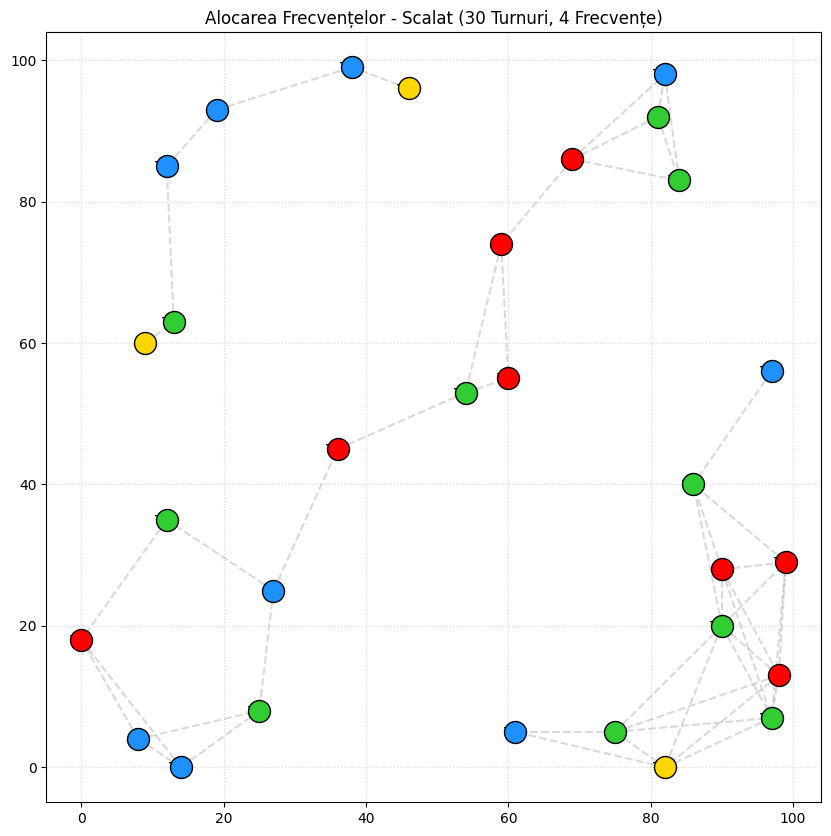

In [25]:
class ScaledFrequencyEnvironment(FrequencyEnvironment):
    def __init__(self, num_towers=30, num_frequencies=4, map_size=100):
        self.num_towers = num_towers
        self.num_frequencies = num_frequencies
        self.action_size = num_frequencies 
        
        self.tower_coords = np.random.randint(0, map_size, size=(num_towers, 2))
        self.interference_matrix = np.zeros((num_towers, num_towers), dtype=np.float32)
        
        for i in range(num_towers):
            for j in range(num_towers):
                if i != j:
                    dist = np.linalg.norm(self.tower_coords[i] - self.tower_coords[j])
                    if dist < 25: 
                        self.interference_matrix[i, j] = 100.0 / (dist + 1.0)
                        
        self.max_possible_interference = np.sum(self.interference_matrix) / 2.0
        
    def __repr__(self):
        return "FrequencyAssignment_Scaled"

def draw_scaled_network(env, state):
    frequencies = state[1:]
    colors = ['red', 'dodgerblue', 'limegreen', 'gold', 'purple', 'cyan']
    
    plt.figure(figsize=(10, 10))
    for i in range(env.num_towers):
        for j in range(i + 1, env.num_towers):
            if env.interference_matrix[i, j] > 0:
                plt.plot([env.tower_coords[i, 0], env.tower_coords[j, 0]], 
                         [env.tower_coords[i, 1], env.tower_coords[j, 1]], 
                         'k--', alpha=0.15)
                
    for i in range(env.num_towers):
        freq = int(frequencies[i])
        color = colors[freq] if freq != -1 else 'gray'
        plt.scatter(env.tower_coords[i, 0], env.tower_coords[i, 1], 
                    c=color, s=250, edgecolors='black', zorder=5)
        plt.text(env.tower_coords[i, 0], env.tower_coords[i, 1], f"T{i}", 
                 color='black', ha='center', va='center', fontweight='bold', fontsize=8)
        
    plt.title(f"Alocarea Frecvențelor - Scalat ({env.num_towers} Turnuri, {env.num_frequencies} Frecvențe)")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.show()


env_scaled = ScaledFrequencyEnvironment(num_towers=30, num_frequencies=4)

model_scaled = FAP_MLP(env_scaled, num_hidden=256, device=device)
optimizer_scaled = torch.optim.Adam(model_scaled.parameters(), lr=0.001, weight_decay=1e-4)

args_scaled = {
    'C': 2.0,
    'num_searches': 120,          
    'num_searches_fast': 30,
    'prob_full_search': 0.25,
    'num_iterations': 1,   
    'num_selfPlay_iterations': 10, 
    'num_epochs': 4,
    'batch_size': 64,             
    'temperature': 1.25,
    'dirichlet_epsilon': 0.25,
    'dirichlet_alpha': 0.3
}

print("\n=== Începem antrenamentul AlphaZero la scară largă (30 Turnuri) ===")
az_agent_scaled = AlphaZeroFAP(model_scaled, optimizer_scaled, env_scaled, args_scaled)
az_agent_scaled.learn()

print("\n=== AI-ul rezolvă rețeaua cu 30 de turnuri ===")
model_scaled.eval()
eval_mcts_scaled = MCTSFAP(env_scaled, args_scaled, model_scaled)
state_scaled = env_scaled.get_initial_state()

while True:
    action_probs = eval_mcts_scaled.search(state_scaled, current_num_searches=200)
    best_action = np.argmax(action_probs)
    
    state_scaled = env_scaled.get_next_state(state_scaled, best_action)
    value, done = env_scaled.get_value_and_terminated(state_scaled, best_action)
    
    if done:
        print("\n--- REZULTAT FINAL ---")
        print(f"Recompensa AI-ului: {value:.3f} (1.0 = Soluție Perfectă)")
        draw_scaled_network(env_scaled, state_scaled)
        break